In [8]:
import numpy as np
import networkx as nx
from collections import defaultdict

from QHyper.converter import Converter
from QHyper.constraint import Polynomial

from dwave.system import DWaveSampler
from dimod import BinaryQuadraticModel

from QHyper.problems.community_detection import CommunityDetectionProblem, Network

Some util function from QHyper

In [9]:
def convert_qubo_keys(qubo: Polynomial) -> tuple[dict[tuple, float], float]:
    new_qubo = defaultdict(float)
    offset = 0.0

    qubo, offset = qubo.separate_const()
    for k, v in qubo.terms.items():
        if len(k) == 1:
            new_key = (k[0], k[0])
        elif len(k) > 2:
            raise ValueError("Only supports quadratic model")
        else:
            new_key = k

        new_qubo[new_key] += v

    return (new_qubo, offset)

Load our biggest graph

In [10]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

#### First let's find clique embedding for graph of 100 nodes
We'll be checking cache'ing behaviour: https://docs.ocean.dwavesys.com/en/stable/docs_minorminer/source/reference/clique_embedding.html#minorminer.busclique.busgraph_cache

In [11]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher

import numpy as np

In [12]:
adv = AdvantageSampler(G, num_reads=100, version="Advantage_system4.1", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)

In [13]:
searcher = HierarchicalSearcher(adv)

In [14]:
r = searcher.hierarchical_community_search(division_tree=True, return_modularities=True, return_metadata=True)

Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'


C:\Users\basia\Desktop\Praca_Inzynierska_2024\QHyper\QHyper\solvers\quantum_annealing\dwave\advantage.py:243: UserWarning: No timing information available for the sampleset. 
  warnings.warn(


Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' object has no attribute 'to_file'
Could not save sampleset to .json file: 'SampleSet' ob

In [19]:
import pickle

with open("adv.pickle", "wb") as f:
    pickle.dump(r, f)

In [20]:
comms, div_tree, div_mods, sampleset_metadata = r

In [11]:
from Qommunity.samplers.hierarchical.gurobi_sampler import GurobiSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [9]:
gur = GurobiSampler(G)
it_searcher = IterativeSearcher(gur)

In [10]:
num_runs = 20

In [11]:
path = "Tutorials/Anneal-Times/Power-law"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-140_samplesets_data.pkl"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-100res-1.25_samplesets_data.pkl"
# result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-{n}_{results}.{format}"
result_path = "../Tutorials/Anneal-Times/Power-Law/PW_n-100_division_trees.npy"

In [21]:
division_tree = div_tree
communities = comms
division_modularities = div_mods

In [20]:
# res = it_searcher.run_with_sampleset_info(num_runs=1, save_results=False)

In [38]:
class Node:
    def __init__(self, id, values, left=None, right=None, parent=None):
        self.id = id
        self.values = values
        self.left = left
        self.right = right
        self.parent = parent

    def __str__(self):
        return f"Node(id={self.id}, values={self.values})"
    
    def __repr__(self):
        return f"Node(values={self.values}, left={self.left}, right={self.right})"
    
    def __eq__(self, node):
        if not isinstance(node, Node):
            return False
        return self.id == node.id and sorted(self.values) == sorted(node.values)

class Tree:
    def __init__(self, root):
        self.root = root
        self.nodes = [root]

In [23]:
division_tree = div_tree

In [39]:
def recover_ordering(division_tree):
    root = Node(id=hash(tuple(G.nodes)), values=list(G.nodes), left=None, right=None, parent=None)
    nodes = {}

    for level in reversed(range(len(division_tree))):
        level_clustering = division_tree[level]

        if level == len(division_tree) - 1:
            for cluster in level_clustering:
                leaf_node = Node(id=hash(tuple(cluster)), values=cluster, left=None, right=None, parent=None)
                nodes[leaf_node.id] = leaf_node
        else:
            subsequent_clusters = division_tree[level + 1]
            subclusters = {}

            for subsequent_cluster in subsequent_clusters: # children clusters
                for cluster in level_clustering: # parent clusters
                    if set(subsequent_cluster).issubset(set(cluster)): # if subsequent cluster is child of the parent
                        key_clus = hash(tuple(cluster))
                        
                        if key_clus not in subclusters.keys():
                            subclusters[key_clus] = subsequent_cluster
                        else:
                            subclusters[key_clus] = (
                                subclusters.get(key_clus),
                                subsequent_cluster,
                            )                    

            for cluster in level_clustering:
                key_clus = hash(tuple(cluster))

                if type(subclusters[key_clus]) == tuple:
                    c0, c1 = subclusters[key_clus]
                    key1, key2 = hash(tuple(c0)), hash(tuple(c1))

                    child_node_1 = nodes[key1]
                    child_node_2 = nodes[key2]

                    parent_node = Node(id=key_clus, values=cluster, left=child_node_1, right=child_node_2, parent=None)
                    nodes[parent_node.id] = parent_node

                    child_node_1.parent = parent_node
                    child_node_2.parent = parent_node
                    
                    # Sanity checks
                    assert child_node_1.parent == parent_node
                    assert child_node_2.parent == parent_node


                # only one subcommunity - list
                elif type(subclusters[key_clus]) == list and level != 0:
                    pass # Nothing to do in here

    root = nodes[root.id]
    return nodes, root

In [40]:
nodes, root = recover_ordering(div_tree)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def build_graph(G, node, level=0):
    """Recursively traverse the binary tree and add edges."""
    if node is None:
        return

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    label = divide_label(node.values)
    mod_value = div_mods[level]
    color = "#4c72b0" if node.left or node.right else "#d35d6e"  # blue for internal, red for leaves
    values = node.values

    G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level)

    if node.left:
        G.add_edge(node.id, node.left.id)
        build_graph(G, node.left, level + 1)
    if node.right:
        G.add_edge(node.id, node.right.id)
        build_graph(G, node.right, level + 1)


def plot_tree(root):
    """Create and visualize the binary tree graph with a modern aesthetic."""
    G = nx.DiGraph()
    build_graph(G, root)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Node classification
    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    # Modern color scheme
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    plt.figure(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                           nodelist=internals,
                           node_color=internal_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=leaves,
                           node_color=leaf_color,
                           node_size=2800,
                           edgecolors="#2b3a42",
                           linewidths=0.8)

    # Draw edges — subtle and transparent
    nx.draw_networkx_edges(G, pos,
                           arrows=False,
                           edge_color="#7d8ca3",
                           width=1.0,
                           alpha=0.6)

    # Draw labels with clean, modern typography
    for node, (x, y) in pos.items():
        node_data = G.nodes[node]
        mod_value = node_data['mod_value']
        color = node_data['color']
        values = node_data['values']

        # label = f"{len(values)}\n{mod_value:.2f}"
        text_color = "white" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label1 = str(len(values))
        # label2 = f"{mod_value:.2f}"
        label1 = f"Pr.size: {len(values)}"
        label2 = f"Ch.str.: {14333}"
        label = label1 + "\n" + label2

        # plt.text(x, y,
        #          label1,
        #          ha="center", va="center",
        #         #  ha="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        # plt.text(x, y-30,
        #          label2,
        #          ha="center", va="center",
        #          fontsize=9,
        #          color=text_color,
        #          fontweight=font_weight,
        #          wrap=True,
        #          bbox=dict(facecolor=color,
        #                    boxstyle="round,pad=0.4",
        #                    edgecolor="#e6e6e6",
        #                    lw=0.8,
        #                    alpha=0.85)
        # )
        plt.text(x, y,
                 label,
                 ha="center", va="center",
                #  ha="center",
                 fontsize=9,
                 color=text_color,
                 fontweight=font_weight,
                 wrap=True,
                 bbox=dict(facecolor=color,
                           boxstyle="round,pad=0.4",
                           edgecolor="#e6e6e6",
                           lw=0.8,
                           alpha=0.85)
        )

    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            plt.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            plt.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
            
    legend_elements = [
        Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"),
        Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"),
    ]

    plt.legend(handles=legend_elements,
            # loc="upper left",   # or "lower right" depending on your layout
            frameon=False,
            fontsize=10)

    plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
import networkx as nx import matplotlib.pyplot as plt from matplotlib.patches import Patch import matplotlib.colors as mcolors import matplotlib.cm as cm def build_graph(G, node, level=0): """Recursively traverse the binary tree and add edges.""" if node is None: return def divide_label(values, len_per_line=6) -> str: lines = [] for i in range(0, len(values), len_per_line): line = values[i:i+len_per_line] lines.append(", ".join(map(str, line))) return "\n".join(lines) label = divide_label(node.values) mod_value = div_mods[level] color = "#4c72b0" if node.left or node.right else "#d35d6e" # blue for internal, red for leaves values = node.values prev_mod_value = div_mods[level - 1] if level > 0 else 0.0 mod_incr = mod_value - prev_mod_value G.add_node(node.id, label=label, mod_value=mod_value, color=color, values=values, level=level, prev_mod_value=prev_mod_value) if node.left: G.add_edge(node.id, node.left.id, length=mod_incr) build_graph(G, node.left, level + 1) if node.right: G.add_edge(node.id, node.right.id, length=mod_incr) build_graph(G, node.right, level + 1) def plot_tree(root): """Create and visualize the binary tree graph with a modern aesthetic.""" G = nx.DiGraph() build_graph(G, root) pos = nx.nx_agraph.graphviz_layout(G, prog="dot") import math for sorted_nodes in sorted(G.nodes(data=True), key=lambda x: x[1]['level'], reverse=True): n, node_data = sorted_nodes print(n, node_data) lvl = node_data["level"] mod_gain = node_data["mod_value"] - node_data["prev_mod_value"] # print(mod_gain) x, y = pos[n] if lvl == 0: y_informed = 0 else: y_informed = abs(math.log(mod_gain)) # print(y, y_informed) children = list(G.successors(n)) if len(children) == 2: # print(len(children)) x1, _ = pos[children[0]] x2, _ = pos[children[1]] new_x = (x1 + x2) / 2 print(f"lvl: {lvl}, child_1_x: {x1}, child_2_x: {x2}, x:{x}, new_x:{new_x}") pos[n] = (new_x, y_informed) # pos[n] = (x, y_informed) else: pos[n] = (x, y_informed) # Node classification leaves = [n for n in G.nodes() if G.out_degree(n) == 0] internals = [n for n in G.nodes() if G.out_degree(n) > 0] labels = nx.get_node_attributes(G, 'label') # Modern color scheme internal_color = "#b8d3e9" leaf_color = "#f2a7a7" plt.figure(figsize=(14, 8)) plt.style.use("seaborn-v0_8-white") # Draw nodes nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color, node_size=2800, edgecolors="#2b3a42", linewidths=0.8) nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color, node_size=2800, edgecolors="#2b3a42", linewidths=0.8) # Draw edges — subtle and transparent nx.draw_networkx_edges(G, pos, arrows=False, edge_color="#7d8ca3", width=1.0, alpha=0.6) # Draw labels with clean, modern typography for node, (x, y) in pos.items(): node_data = G.nodes[node] mod_value = node_data['mod_value'] color = node_data['color'] values = node_data['values'] # label = f"{len(values)}\n{mod_value:.2f}" text_color = "white" if node in leaves else "#1e2a36" font_weight = "bold" if node in leaves else "semibold" # label1 = str(len(values)) # label2 = f"{mod_value:.2f}" label1 = f"Pr.size: {len(values)}" label2 = f"Ch.str.: {14333}" label = label1 + "\n" + label2 # prev_mod_value = node_data['prev_mod_value'] # print(f"Node: {node}, Prev. Modularity: {prev_mod_value}") # plt.text(x, y, # label1, # ha="center", va="center", # # ha="center", # fontsize=9, # color=text_color, # fontweight=font_weight, # wrap=True, # bbox=dict(facecolor=color, # boxstyle="round,pad=0.4", # edgecolor="#e6e6e6", # lw=0.8, # alpha=0.85) # ) # plt.text(x, y-30, # label2, # ha="center", va="center", # fontsize=9, # color=text_color, # fontweight=font_weight, # wrap=True, # bbox=dict(facecolor=color, # boxstyle="round,pad=0.4", # edgecolor="#e6e6e6", # lw=0.8, # alpha=0.85) # ) plt.text(x, y, label, ha="center", va="center", # ha="center", fontsize=9, color=text_color, fontweight=font_weight, wrap=True, bbox=dict(facecolor=color, boxstyle="round,pad=0.4", edgecolor="#e6e6e6", lw=0.8, alpha=0.85) ) levels = sorted(set(nx.get_node_attributes(G, 'level').values())) modularities = [div_mods[l] for l in levels] # Annotate modularity per level at the right of the plot xmax = max(x for x, y in pos.values()) pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0])) last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2] dx = abs(last_2[0] - last_1[0]) for lvl, m in zip(levels, modularities): # Find nodes at this level nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl] # print("!", lvl, np.mean([pos[n][1] for n in nodes_at_level])) # print("?", lvl, [pos[n][1] for n in nodes_at_level]) y = np.mean([pos[n][1] for n in nodes_at_level]) if lvl == 0: y = 0.0 if nodes_at_level: # Use mean X position of nodes at this level for placement plt.text(xmax + dx, y, f"{m:.4f}", ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold") plt.hlines(y=y, xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx, colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6) legend_elements = [ Patch(facecolor=internal_color, edgecolor="#2b3a42", label="Internal nodes"), Patch(facecolor=leaf_color, edgecolor="#2b3a42", label="Leaf nodes"), ] plt.legend(handles=legend_elements, # loc="upper left", # or "lower right" depending on your layout frameon=False, fontsize=10) plt.title("Chain strength & problem size in the hierarchical division tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20) plt.axis("off") plt.tight_layout() plt.show() return G

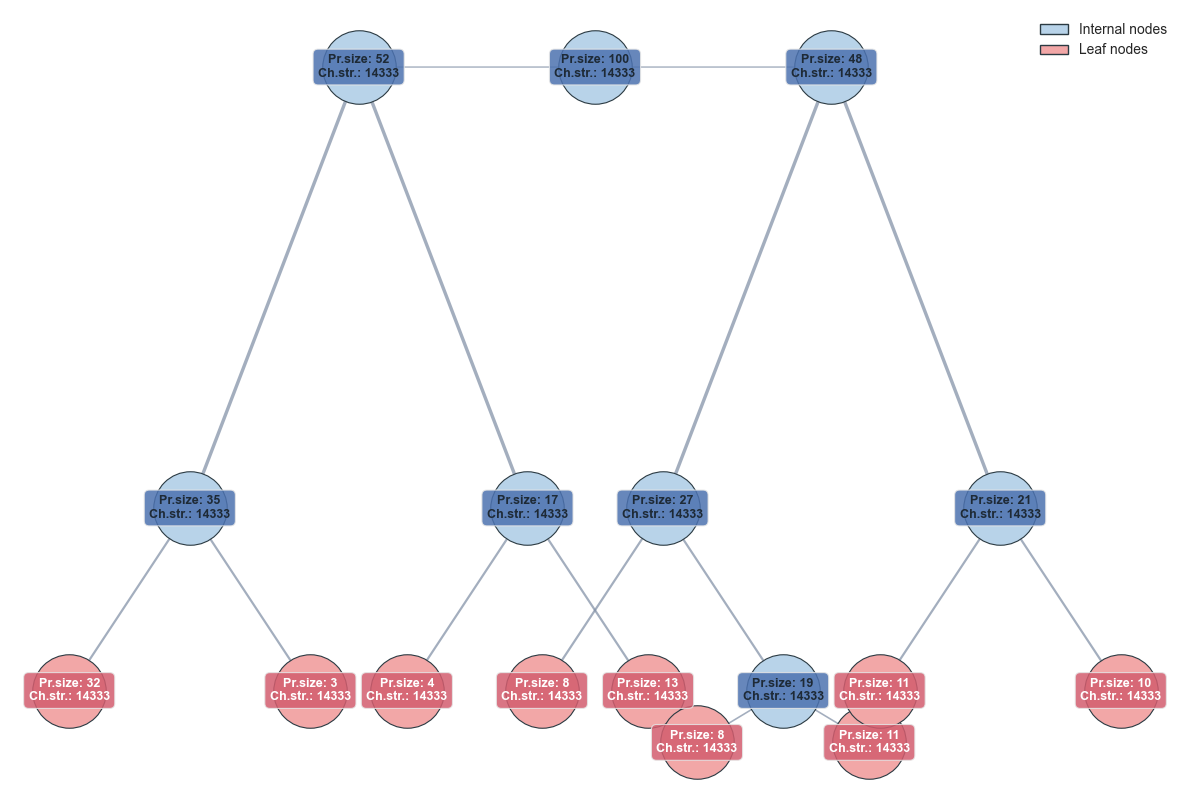

(<networkx.classes.digraph.DiGraph at 0x21a8a3d9d50>,
 {4479737025582696436: (0.0, 0),
  -5183549540891213786: (-3.0, 0.0),
  2881213616258492590: (-5.142857142857142, -4.785225997347209),
  508968978265049823: (-6.673469387755102, -6.766146311600857),
  4244552301997251146: (-3.612244897959183, -6.766146311600857),
  4193444540149848452: (-0.8571428571428572, -4.785225997347209),
  7673536023032186979: (-2.3877551020408165, -6.766146311600857),
  -5921050210639668839: (0.6734693877551021, -6.766146311600857),
  -2058050933222242708: (3.0, 0.0),
  5545949054900359967: (0.8571428571428572, -4.785225997347209),
  -6539798361249740001: (-0.6734693877551021, -6.766146311600857),
  3238314728115489754: (2.3877551020408165, -6.766146311600857),
  -2045999771114126478: (1.2944606413994169, -7.329354147535967),
  -2251870041769838549: (3.481049562682216, -7.329354147535967),
  -1781945651135785683: (5.142857142857142, -4.785225997347209),
  7257540054485854263: (3.612244897959183, -6.766146311

In [66]:
plot_tree(root)

In [67]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_tree_with_modularity_axis(root):
    """Original modern tree layout with modularity axis annotations."""
    G = nx.DiGraph()
    build_graph(G, root)  # your existing build_graph function
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
    internals = [n for n in G.nodes() if G.out_degree(n) > 0]
    labels = nx.get_node_attributes(G, 'label')

    def divide_label(values, len_per_line=6) -> str:
        lines = []
        for i in range(0, len(values), len_per_line):
            line = values[i:i+len_per_line]
            lines.append(", ".join(map(str, line)))
        return "\n".join(lines)

    fig, ax = plt.subplots(figsize=(14, 8))
    plt.style.use("seaborn-v0_8-white")

    # Node colors
    internal_color = "#b8d3e9"
    leaf_color = "#f2a7a7"

    node_size = 2800

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=internals, node_color=internal_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=leaves, node_color=leaf_color,
                           node_size=node_size, edgecolors="#2b3a42", linewidths=0.8, ax=ax)

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=False, edge_color="#7d8ca3", width=1.0, alpha=0.6, ax=ax)

    # Draw node labels
    for node, (x, y) in pos.items():
        data = G.nodes[node]
        # mod_value = data['mod_value']
        values = data['values']
        text_color = "black" if node in leaves else "#1e2a36"
        font_weight = "bold" if node in leaves else "semibold"
        # label = f"{len(values)}"
        lvl = data["level"]
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        n_nodes = len(nodes_at_level)
        if n_nodes in [1]:
            max_items_per_line = len(values) // 2
        elif n_nodes in [2]:
            max_items_per_line = 10
        else:
            max_items_per_line = 4

        label = divide_label(values, max_items_per_line)
        label = "[" + label + "]"     

        # plt.text(x, y, label,
        #          ha="center", va="center",
        #          fontsize=9, color=text_color, fontweight=font_weight,
        #          wrap=True, zorder=4)
        plt.text(x, y, label,
                 ha="center", va="center",
                 fontsize=9, color=text_color, fontweight=font_weight,
                 wrap=True, zorder=4)

    # --- Add modularity axis on the right ---
    # Get all unique levels and modularities
    levels = sorted(set(nx.get_node_attributes(G, 'level').values()))
    modularities = [div_mods[l] for l in levels]

    # Annotate modularity per level at the right of the plot
    xmax = max(x for x, y in pos.values())
    pos_values_sorted = sorted(pos.values(), key=lambda x: (x[1], x[0]))
    last_1, last_2 = pos_values_sorted[-1], pos_values_sorted[-2]
    dx = abs(last_2[0] - last_1[0])
    for lvl, m in zip(levels, modularities):
        # Find nodes at this level
        nodes_at_level = [n for n, d in G.nodes(data=True) if d['level'] == lvl]
        if nodes_at_level:
            # Use mean X position of nodes at this level for placement
            mean_x = sum(pos[n][0] for n in nodes_at_level) / len(nodes_at_level)
            ax.text(xmax + dx, np.mean([pos[n][1] for n in nodes_at_level]), f"{m:.4f}",
                     ha="left", va="center", fontsize=9, color="#444444", fontweight="semibold")
            
            ax.hlines(y=np.mean([pos[n][1] for n in nodes_at_level]),
                      xmin=(xmax+dx) - (xmax+dx/2), xmax=xmax+dx,
                      colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)
    
    y_coords_end = max(pos[n][1] for n in nodes_at_level)
    nodes_at_0 = [n for n, d in G.nodes(data=True) if d['level'] == 0]
    y_coords_start = min([pos[n][1] for n in nodes_at_0])
    # ax.vlines(x=xmax+dx / 2, ymin=y_coords_start, ymax=y_coords_end,  # extend slightly above/below
    #           colors="#bbbbbb", linestyles="dashed", lw=0.8, alpha=0.6)

    ax.set_title("Hierarchcial Division Tree", fontsize=16, fontweight="bold", color="#2b3a42", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


c:\Users\basia\anaconda3\envs\qomm_env\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\basia\anaconda3\envs\qomm_env\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


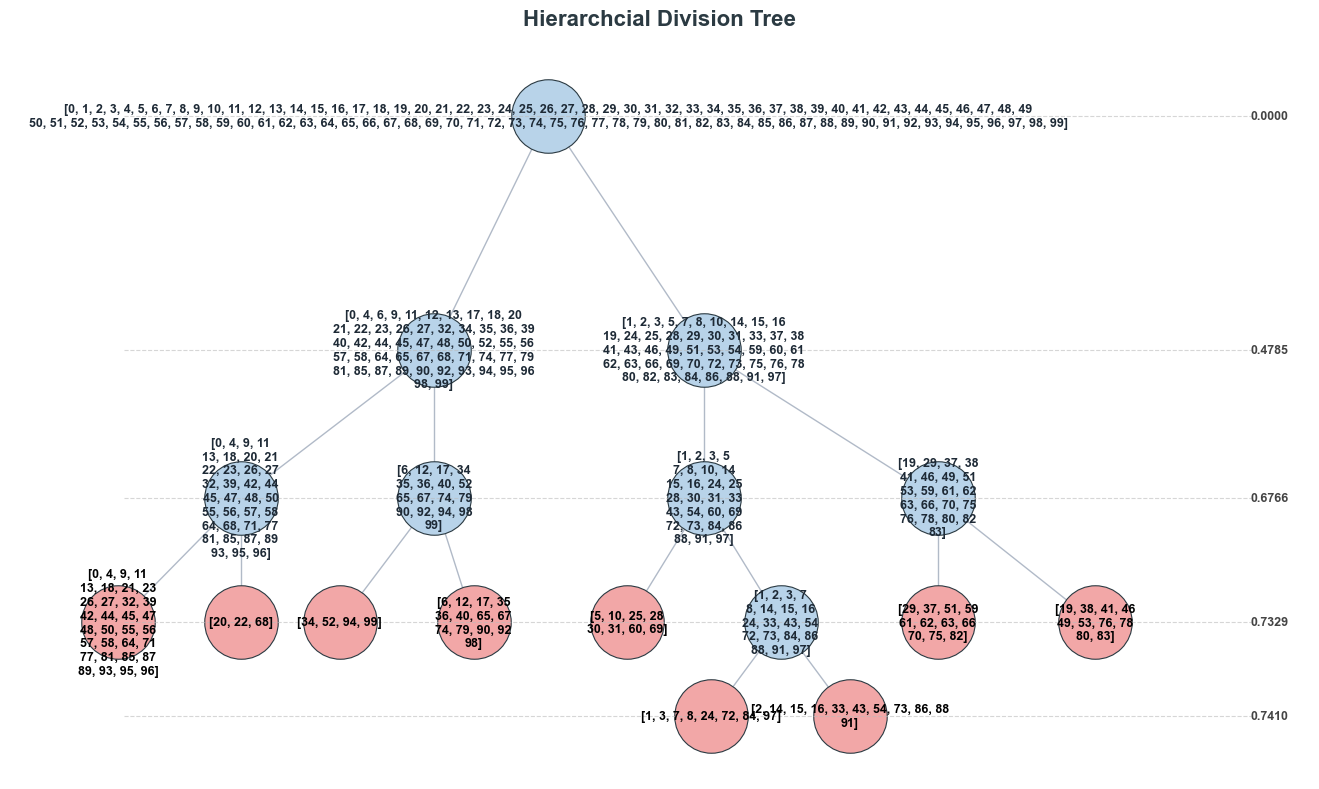

In [55]:
plot_tree_with_modularity_axis(root)